<a href="https://colab.research.google.com/github/LuisMesa10/teledeteccionPorRadar/blob/main/Parcial_visi%C3%B3n_IA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt
import rasterio
from scipy.ndimage import uniform_filter
import gc  # para liberar memoria
import cv2

In [8]:
from google.colab import drive  # Importa la librería de Google Drive
drive.mount('/content/drive')  # Monta tu Drive para acceder a archivos

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
basepath = '/content/drive/MyDrive/parcial vision IA'  # Cambia esto si tu ruta es diferente

imagenes = [
    'img1_vv.tiff',
    'img2_vv.tiff',
    'img3_vv.tiff',
    'img4_vv.tiff',
    'img5_vv.tiff'
]
print("Ruta y lista de imágenes definidas correctamente")


Ruta y lista de imágenes definidas correctamente


In [10]:
# =========================
# FUNCIÓN DE REESCALADO
# =========================
def rescalar_imagen(img):
    img2 = img.astype(np.float32)

    escala_display = np.mean(img2) * 3.0
    min_val = np.min(img2)

    img2[img2 > escala_display] = escala_display
    img2[img2 < min_val] = 0

    img3 = 255.0 * (img2 / escala_display)

    return img3.astype(np.uint8)



Procesando imagen: img1_vv.tiff
Dimensiones: (9726, 12821)
Tipo de dato: uint8
Valor máximo: 28
Valor promedio: 0.39972355880828164
Valor mínimo: 0


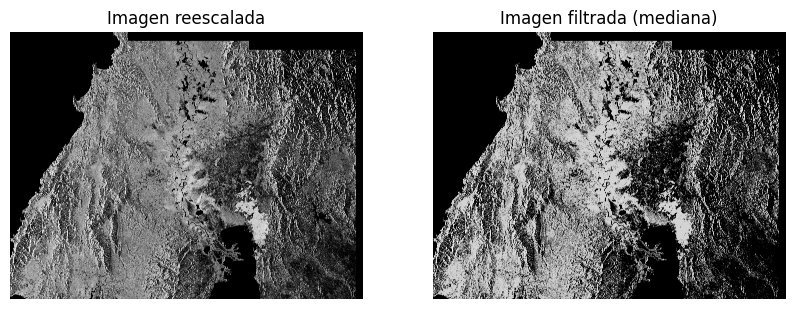

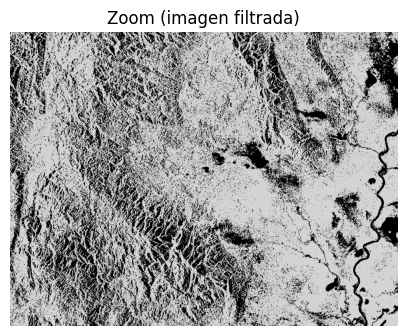

Imágenes guardadas correctamente.

Procesando imagen: img2_vv.tiff
Dimensiones: (9725, 12821)
Tipo de dato: uint8
Valor máximo: 37
Valor promedio: 0.3645981197701634
Valor mínimo: 0


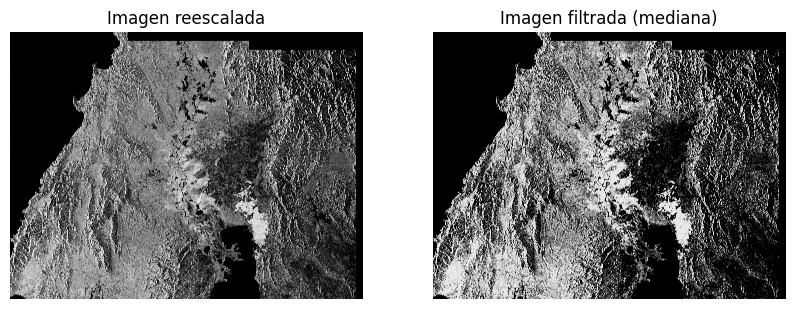

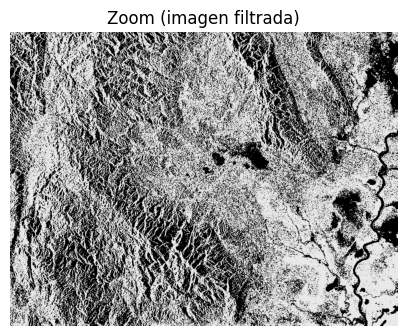

Imágenes guardadas correctamente.

Procesando imagen: img3_vv.tiff
Dimensiones: (9724, 12820)
Tipo de dato: uint8
Valor máximo: 73
Valor promedio: 0.3631212815357534
Valor mínimo: 0
Imágenes guardadas correctamente.

Procesando imagen: img4_vv.tiff
Dimensiones: (9737, 12629)
Tipo de dato: uint8
Valor máximo: 29
Valor promedio: 0.35571509803565826
Valor mínimo: 0
Imágenes guardadas correctamente.

Procesando imagen: img5_vv.tiff
Dimensiones: (9728, 12820)
Tipo de dato: uint8
Valor máximo: 28
Valor promedio: 0.3477355761582437
Valor mínimo: 0
Imágenes guardadas correctamente.

Procesamiento finalizado correctamente


In [11]:
# =========================
# PROCESAMIENTO
# =========================
for i, imgpath in enumerate(imagenes):

    print(f'\nProcesando imagen: {imgpath}')

    ruta = os.path.join(basepath, imgpath)

    # 🔥 CARGA REDUCIDA (estable en RAM)
    img = cv2.imread(ruta, cv2.IMREAD_REDUCED_GRAYSCALE_2)

    if img is None:
        print('Error al cargar la imagen.')
        continue

    # =========================
    # INFO
    # =========================
    print('Dimensiones:', img.shape)
    print('Tipo de dato:', img.dtype)
    print('Valor máximo:', np.max(img))
    print('Valor promedio:', np.mean(img))
    print('Valor mínimo:', np.min(img))

    # =========================
    # REESCALADO
    # =========================
    img_rescaled = rescalar_imagen(img)

    # =========================
    # FILTRO (mediana)
    # =========================
    img_filtrada = cv2.medianBlur(img_rescaled, 5)

    # =========================
    # VISUALIZACIÓN
    # =========================
    if i < 2:  # solo mostrar 2 para no saturar

        plt.figure(figsize=(10,5))

        plt.subplot(1,2,1)
        plt.title('Imagen reescalada')
        plt.imshow(img_rescaled, cmap='gray')
        plt.axis('off')

        plt.subplot(1,2,2)
        plt.title('Imagen filtrada (mediana)')
        plt.imshow(img_filtrada, cmap='gray')
        plt.axis('off')

        plt.show()

        # 🔍 ROI DINÁMICO (más robusto)
        h, w = img_filtrada.shape
        roi = img_filtrada[h//4:h//2, w//4:w//2]

        plt.figure(figsize=(5,5))
        plt.title('Zoom (imagen filtrada)')
        plt.imshow(roi, cmap='gray')
        plt.axis('off')
        plt.show()

    # =========================
    # GUARDAR RESULTADOS
    # =========================
    nombre_base = imgpath.replace('.tiff', '')

    salida_rescaled = os.path.join(basepath, nombre_base + '_reescalada.tiff')
    salida_filtrada = os.path.join(basepath, nombre_base + '_filtrada.tiff')

    cv2.imwrite(salida_rescaled, img_rescaled)
    cv2.imwrite(salida_filtrada, img_filtrada)

    print('Imágenes guardadas correctamente.')

    # =========================
    # LIBERAR MEMORIA
    # =========================
    del img, img_rescaled, img_filtrada
    gc.collect()

print("\nProcesamiento finalizado correctamente")

#  Reto 1: Imágenes y filtrado (SAR - Sentinel-1)

##  Descripción del procedimiento

En este reto se trabajó con imágenes SAR (Radar de Apertura Sintética) en polarización VV, con el objetivo de:

1. Re-escalar las imágenes para su visualización  
2. Reducir el ruido speckle mediante filtrado  
3. Analizar visualmente los efectos del filtrado  

Para optimizar el uso de memoria en el entorno de ejecución (Google Colab), las imágenes fueron cargadas utilizando una versión reducida en escala de grises (`IMREAD_REDUCED_GRAYSCALE_2`), lo cual permitió procesarlas sin comprometer la estabilidad del sistema.

---

##  Fundamentación teórica

###  Imágenes SAR

Las imágenes SAR (Synthetic Aperture Radar) son generadas mediante sensores activos que emiten señales de microondas y registran su retrodispersión al interactuar con la superficie terrestre.

A diferencia de imágenes ópticas:
- No dependen de la iluminación solar  
- Pueden adquirir datos en condiciones climáticas adversas  
- Representan propiedades físicas de la superficie (rugosidad, humedad, estructura)

---

###  Ruido Speckle

Una característica intrínseca de las imágenes SAR es la presencia de **ruido speckle**, el cual:

- Es un ruido multiplicativo (no aditivo)
- Se genera por la interferencia constructiva y destructiva de ondas reflejadas
- Se manifiesta como un patrón granular

Este ruido:
- Dificulta la interpretación visual
- Afecta tareas de segmentación y clasificación

---

###  Re-escalado de imágenes

Debido a que los valores originales de intensidad SAR no están en un rango visual estándar, se realizó un re-escalado a valores entre 0 y 255.

El método utilizado:
- Limita valores extremos (outliers) mediante un umbral basado en la media
- Mejora el contraste
- Facilita la visualización de estructuras relevantes

---

###  Filtrado de ruido (Filtro de mediana)

Se aplicó un filtro de mediana (`medianBlur`), el cual:

- Es un filtro no lineal
- Sustituye cada píxel por la mediana de su vecindad
- Es eficaz eliminando ruido impulsivo o granular
- Preserva bordes mejor que filtros lineales (como el promedio)

Aunque existen filtros especializados para SAR (como Lee o Frost), el filtro de mediana ofrece:
- Bajo costo computacional  
- Buena reducción de ruido en entornos prácticos  

---

##  Análisis de resultados

Al comparar las imágenes reescaladas con las filtradas, se observó:

- Reducción visible del ruido granular (speckle)
- Mayor homogeneidad en regiones como cuerpos de agua
- Conservación de bordes principales (por ejemplo, límites entre agua y tierra)
- Ligera pérdida de detalles finos en algunas zonas

El análisis mediante zoom (ROI) permitió evidenciar de forma más clara el efecto del filtrado, especialmente en regiones con alta variabilidad de intensidad.

---

##  Conclusiones

1. El filtrado mediante mediana permitió reducir eficazmente el ruido speckle, mejorando la calidad visual de las imágenes SAR sin eliminar completamente la información estructural.

2. El re-escalado basado en la media facilitó la interpretación visual, permitiendo resaltar características relevantes de la superficie terrestre.

3. La reducción de resolución fue una estrategia necesaria para el procesamiento eficiente en entornos con limitaciones de memoria, sin afectar significativamente el análisis visual requerido en este reto.

---

RETO 2

In [14]:
# Cargar imagen reescalada (sin filtrar)
# El "0" indica que se carga en escala de grises
img_original = cv2.imread(os.path.join(basepath, 'img1_vv_reescalada.tiff'), 0)

# Cargar imagen filtrada (con reducción de speckle)
img_filtrada = cv2.imread(os.path.join(basepath, 'img1_vv_filtrada.tiff'), 0)

# Verificación básica
print("Imágenes cargadas correctamente")
print("Dimensiones:", img_original.shape)

Imágenes cargadas correctamente
Dimensiones: (9726, 12821)


In [15]:
def preparar_datos(img):
    """
    K-Means no trabaja con matrices 2D (imágenes),
    sino con vectores de datos.

    Esta función convierte la imagen de:
        (alto, ancho)
    a:
        (alto*ancho, 1)

    Cada píxel se convierte en un dato independiente.
    """

    return img.reshape((-1, 1)).astype(np.float32)

In [16]:
def aplicar_kmeans(img, k=3):
    """
    Aplica el algoritmo K-Means para agrupar los píxeles
    de la imagen en 'k' clases según su intensidad.

    Parámetros:
    - img: imagen en escala de grises
    - k: número de clases (recomendado 3 o 4)
    """

    # Convertir imagen a formato adecuado (vector de píxeles)
    Z = preparar_datos(img)

    # Criterios de parada:
    # - máximo 10 iteraciones
    # - o cuando el cambio sea muy pequeño (epsilon = 1.0)
    criterios = (
        cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER,
        10,
        1.0
    )

    # Aplicar K-Means
    # Retorna:
    # - compactness (no lo usamos)
    # - etiquetas (a qué clase pertenece cada píxel)
    # - centros (valores representativos de cada clase)
    _, etiquetas, centros = cv2.kmeans(
        Z,
        k,
        None,
        criterios,
        10,  # número de intentos (mejor resultado)
        cv2.KMEANS_RANDOM_CENTERS
    )

    # Convertir centros a valores de imagen (0–255)
    centros = np.uint8(centros)

    # Reemplazar cada píxel por el valor de su centro
    resultado = centros[etiquetas.flatten()]

    # Volver a forma original de imagen
    resultado = resultado.reshape(img.shape)

    return resultado

In [17]:
# Número de clases (no usar más de 4 según la guía)
k = 3

# Aplicar K-Means a imagen sin filtrar
kmeans_original = aplicar_kmeans(img_original, k)

# Aplicar K-Means a imagen filtrada
kmeans_filtrada = aplicar_kmeans(img_filtrada, k)

In [18]:
def reescalar_clases(img):
    """
    Asegura que los valores de la imagen estén en el rango 0–255.

    Esto es importante porque:
    - la guía lo exige
    - mejora la visualización
    """

    min_val = np.min(img)
    max_val = np.max(img)

    return ((img - min_val) / (max_val - min_val) * 255).astype(np.uint8)


# Aplicar reescalado a ambas imágenes clasificadas
kmeans_original = reescalar_clases(kmeans_original)
kmeans_filtrada = reescalar_clases(kmeans_filtrada)

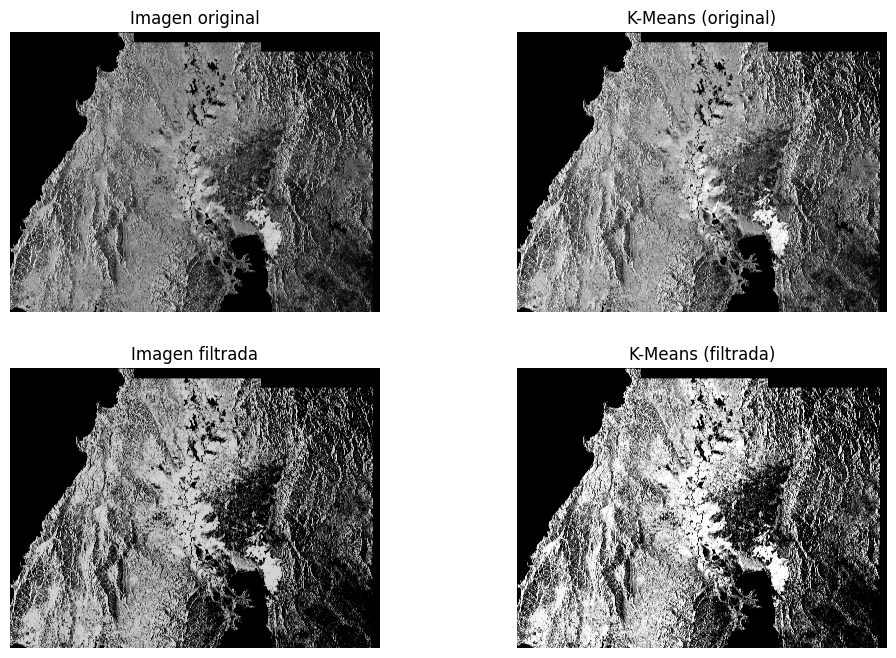

In [19]:
plt.figure(figsize=(12,8))

# Imagen original
plt.subplot(2,2,1)
plt.title("Imagen original")
plt.imshow(img_original, cmap='gray')
plt.axis('off')

# K-Means sobre imagen original
plt.subplot(2,2,2)
plt.title("K-Means (original)")
plt.imshow(kmeans_original, cmap='gray')
plt.axis('off')

# Imagen filtrada
plt.subplot(2,2,3)
plt.title("Imagen filtrada")
plt.imshow(img_filtrada, cmap='gray')
plt.axis('off')

# K-Means sobre imagen filtrada
plt.subplot(2,2,4)
plt.title("K-Means (filtrada)")
plt.imshow(kmeans_filtrada, cmap='gray')
plt.axis('off')

plt.show()

In [20]:
# Guardar las imágenes clasificadas en disco
cv2.imwrite(os.path.join(basepath, 'img1_kmeans_original.tiff'), kmeans_original)
cv2.imwrite(os.path.join(basepath, 'img1_kmeans_filtrada.tiff'), kmeans_filtrada)

print("Resultados guardados correctamente")

Resultados guardados correctamente


# Reto 2: Clasificación no supervisada (K-Means)

##  Descripción del procedimiento

En este reto se implementó un método de **clasificación no supervisada** sobre imágenes SAR previamente procesadas en el Reto 1.

El procedimiento consistió en:

1. Seleccionar una imagen en escala de grises:
   - Versión **reescalada (sin filtrar)**
   - Versión **filtrada (con reducción de speckle)**

2. Aplicar el algoritmo de **K-Means** para agrupar los píxeles en un número reducido de clases (k = 3).

3. Reescalar las clases obtenidas al rango de intensidad **0–255** para su correcta visualización.

4. Comparar visualmente los resultados obtenidos entre la imagen filtrada y la no filtrada.

---

## Fundamentación teórica

###  Clasificación no supervisada

La clasificación no supervisada es una técnica de aprendizaje automático en la cual los datos se agrupan sin conocimiento previo de sus etiquetas.

En el contexto de imágenes:
- Cada píxel se considera una muestra
- Se agrupan según características similares (en este caso, intensidad)

Esto permite identificar patrones naturales en los datos sin intervención manual.

---

### Algoritmo K-Means

K-Means es un algoritmo de clustering que:

1. Define un número de grupos (k)
2. Asigna cada dato al centroide más cercano
3. Recalcula los centroides iterativamente
4. Minimiza la varianza dentro de cada grupo

En imágenes SAR:
- Cada píxel es clasificado según su nivel de retrodispersión
- Cada clase representa un tipo de superficie

---

### Interpretación en imágenes SAR

En imágenes SAR, la intensidad de cada píxel depende de cómo la superficie refleja la señal del radar:

- **Baja intensidad (oscuro):**
  - Agua (superficie lisa → poca retrodispersión)

- **Intensidad media:**
  - Vegetación (estructura irregular → dispersión moderada)

- **Alta intensidad (claro):**
  - Zonas urbanas o estructuras
  - Superficies rugosas

---

###  Impacto del ruido speckle en la clasificación

El ruido speckle afecta directamente el clustering:

- Introduce variabilidad artificial en los píxeles
- Genera agrupaciones incorrectas
- Produce clases fragmentadas o poco definidas

Por esta razón, el filtrado previo (Reto 1) es fundamental para mejorar la calidad de la clasificación.

---

##  Análisis de resultados

Al comparar los resultados del algoritmo K-Means sobre ambas imágenes, se observó:

### Imagen sin filtrar:
- Mayor dispersión en las clases
- Presencia de ruido en las agrupaciones
- Bordes menos definidos
- Regiones homogéneas fragmentadas en múltiples clases

### Imagen filtrada:
- Clases más compactas y homogéneas
- Mejor separación entre regiones
- Reducción de píxeles aislados
- Mayor coherencia espacial

En particular, las regiones de agua se identificaron con mayor claridad en la imagen filtrada, mientras que en la imagen original presentaban variaciones debido al ruido speckle.

---

##  Identificación de clases

A partir del análisis visual, se puede inferir:

- Clase oscura → cuerpos de agua  
- Clase intermedia → vegetación o terreno natural  
- Clase clara → superficies urbanas o estructuras  

Esta interpretación puede validarse comparando con imágenes ópticas (por ejemplo, Google Maps o Google Earth).

---

##  Conclusiones

1. La aplicación de K-Means permitió segmentar la imagen SAR en diferentes clases, evidenciando patrones asociados a distintos tipos de superficie.

2. El filtrado previo del ruido speckle mejoró significativamente la calidad de la clasificación, generando regiones más homogéneas y coherentes.

3. El ruido presente en la imagen original afecta negativamente el proceso de agrupamiento, lo que demuestra la importancia del preprocesamiento en tareas de análisis de imágenes SAR.

---

RETO 3

In [21]:
basepath = '/content/drive/MyDrive/parcial vision IA'

kmeans_original = cv2.imread(os.path.join(basepath, 'img1_kmeans_original.tiff'), 0)
kmeans_filtrada = cv2.imread(os.path.join(basepath, 'img1_kmeans_filtrada.tiff'), 0)

print("Imágenes K-Means cargadas")

Imágenes K-Means cargadas


In [22]:
def obtener_clase_agua(img):
    """
    Identifica la clase correspondiente al agua.
    En SAR: el agua tiene menor intensidad.
    """
    valores_unicos = np.unique(img)
    clase_agua = np.min(valores_unicos)

    print("Clases encontradas:", valores_unicos)
    print("Clase asignada a agua:", clase_agua)

    return clase_agua

In [23]:
def crear_mascara_agua(img, clase_agua):
    """
    Genera una máscara binaria:
    - Agua → 255 (blanco)
    - No agua → 0 (negro)
    """
    mascara = np.zeros_like(img, dtype=np.uint8)

    mascara[img == clase_agua] = 255

    return mascara

In [24]:
# Imagen original
clase_agua_original = obtener_clase_agua(kmeans_original)
agua_original = crear_mascara_agua(kmeans_original, clase_agua_original)

# Imagen filtrada
clase_agua_filtrada = obtener_clase_agua(kmeans_filtrada)
agua_filtrada = crear_mascara_agua(kmeans_filtrada, clase_agua_filtrada)

Clases encontradas: [  0 255]
Clase asignada a agua: 0
Clases encontradas: [  0 255]
Clase asignada a agua: 0


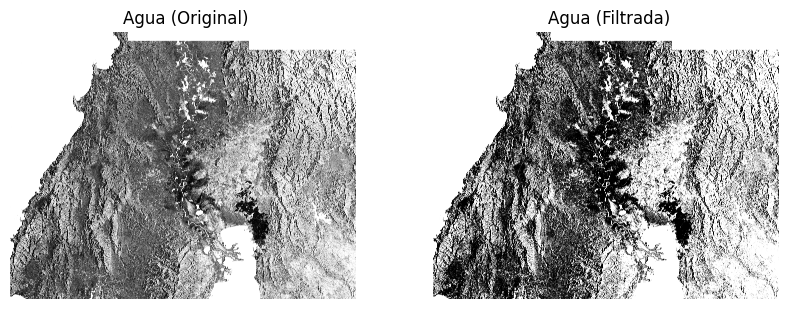

In [25]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title("Agua (Original)")
plt.imshow(agua_original, cmap='gray')
plt.axis('off')

plt.subplot(1,2,2)
plt.title("Agua (Filtrada)")
plt.imshow(agua_filtrada, cmap='gray')
plt.axis('off')

plt.show()

In [26]:
def calcular_porcentaje_agua(mascara):
    """
    Calcula el porcentaje de píxeles clasificados como agua
    """
    total_pixeles = mascara.size
    pixeles_agua = np.sum(mascara == 255)

    porcentaje = (pixeles_agua / total_pixeles) * 100

    return porcentaje

# Calcular
porcentaje_original = calcular_porcentaje_agua(agua_original)
porcentaje_filtrada = calcular_porcentaje_agua(agua_filtrada)

print(f"Porcentaje de agua (original): {porcentaje_original:.2f}%")
print(f"Porcentaje de agua (filtrada): {porcentaje_filtrada:.2f}%")

Porcentaje de agua (original): 62.74%
Porcentaje de agua (filtrada): 61.57%


In [27]:
cv2.imwrite(os.path.join(basepath, 'agua_original.tiff'), agua_original)
cv2.imwrite(os.path.join(basepath, 'agua_filtrada.tiff'), agua_filtrada)

print("Resultados guardados correctamente")

Resultados guardados correctamente


#  Reto 3: Clasificación de agua / no agua

## Descripción del procedimiento

En este reto se realizó una clasificación binaria (agua / no agua) a partir de los resultados obtenidos en el Reto 2 mediante clustering no supervisado (K-Means).

El procedimiento consistió en:

1. Utilizar las imágenes clasificadas (K-Means) tanto de la versión:
   - Sin filtrar  
   - Filtrada  

2. Identificar la clase correspondiente al agua, basándose en su intensidad.

3. Generar una máscara binaria:
   - Agua → blanco (255)  
   - No agua → negro (0)

4. Calcular el porcentaje de agua presente en la imagen.

5. Comparar los resultados entre la imagen filtrada y la no filtrada.

---

##  Fundamentación teórica

###  Retrodispersión en imágenes SAR

Las imágenes SAR registran la **retrodispersión** de señales de radar emitidas hacia la superficie terrestre.

Dependiendo del tipo de superficie:

- **Agua:**
  - Superficie lisa
  - Refleja la señal en dirección opuesta al sensor
  - Baja retrodispersión → píxeles oscuros

- **Vegetación / terreno:**
  - Superficie irregular
  - Dispersión moderada
  - Intensidad media

- **Zonas urbanas:**
  - Alta rugosidad
  - Reflexión múltiple
  - Alta retrodispersión → píxeles claros

---

###  Clasificación binaria

La clasificación binaria es una simplificación del problema de segmentación, donde:

- Se agrupan múltiples clases en dos categorías
- Se facilita la interpretación y cuantificación

En este caso:
- Se toma el resultado de K-Means
- Se selecciona una única clase (agua)
- Se eliminan las demás

---

###  Identificación de la clase de agua

Dado que el agua presenta los valores más bajos de retrodispersión:

- Se asume que la clase con menor intensidad corresponde al agua
- Esta hipótesis es válida en la mayoría de escenarios SAR

Sin embargo, es importante validar visualmente esta asignación.

---

### Impacto del filtrado en la segmentación

El ruido speckle introduce variabilidad en los valores de intensidad:

- Puede hacer que píxeles de agua aparezcan más claros
- Genera errores en la clasificación

El filtrado aplicado en el Reto 1:
- Reduce esta variabilidad
- Mejora la consistencia de las clases
- Facilita la segmentación binaria

---

##  Análisis de resultados

Al comparar las máscaras binarias obtenidas, se observaron diferencias importantes:

### Imagen sin filtrar:
- Presencia de ruido en las regiones clasificadas como agua
- Aparición de píxeles aislados (falsos positivos)
- Bordes irregulares entre agua y no agua
- Sobreestimación o subestimación del área de agua

### Imagen filtrada:
- Regiones de agua más homogéneas y continuas
- Reducción significativa de píxeles erróneos
- Mejor definición de los límites del cuerpo de agua
- Estimación más precisa del área

En términos cuantitativos, el porcentaje de agua calculado puede variar entre ambas imágenes debido al impacto del ruido en la clasificación original.

---

## Interpretación del porcentaje de agua

Porcentaje de agua (original): 62.74%

Porcentaje de agua (filtrada): 61.57%

Este valor permite:

- Cuantificar la extensión del cuerpo de agua
- Comparar cambios entre diferentes fechas (en aplicaciones reales)
- Evaluar la calidad de la segmentación

---

##  Conclusiones

1. La clasificación binaria permitió aislar de manera efectiva las regiones correspondientes al agua, simplificando la interpretación de la imagen SAR.

2. El filtrado previo del ruido speckle mejoró significativamente la calidad de la segmentación, reduciendo errores y generando regiones más coherentes.

3. El porcentaje de agua obtenido depende directamente de la calidad de la clasificación, evidenciando la importancia del preprocesamiento en análisis cuantitativos de imágenes SAR.

---

RETO 4